NAV Domain — DF Path - End-to-End Analysis

```
NAV Domain Data
Objective: NAV data service - End-to-End
📂Project Root : ardupilot-nav-domain-poc
📂Location of bin file : /bin/vault/df_source/nav_calibrated_final.BIN
📂Location of nav_df_master.parquet: /home/ni/ardupilot-nav-domain-poc/bin/vault/warehouse_df/
```

In [26]:
import os
import duckdb
import pandas as pd
from pathlib import Path

# 1. Setup the Path to your 'Gold' Parquet file
# Adjust this to where your SITL results are stored
PARQUET_PATH = Path.home() / "bin/vault/warehouse_df/nav_df_master.parquet"

def get_parquet_data():
    """Reads the master Parquet file directly using DuckDB."""
    if not PARQUET_PATH.exists():
        raise FileNotFoundError(f"❌ Parquet file not found at {PARQUET_PATH}")

    # We use an in-memory connection to query the file on disk
    con = duckdb.connect(database=':memory:')

    # SQL query to grab clean data (Filtering 'Null Island' 0,0)
    query = f"SELECT * FROM read_parquet('{PARQUET_PATH}') WHERE Lat != 0"

    df = con.execute(query).df()
    con.close()
    return df

#

In [27]:
import os
from pathlib import Path

# 1. Get the current directory (where the notebook sits)
current_path = Path.cwd()

# 2. Move up to the project root: ardupilot-nav-domain-poc
# Since you are in src/df_domain_data_services, we go up 2 levels
project_root = current_path.parents[1]

# 3. Construct the path relative to the PROJECT ROOT
warehouse_dir = project_root / "bin" / "vault" / "warehouse_df"
parquet_file = warehouse_dir / "nav_df_master.parquet"

print(f"Project Root Identified: {project_root}")
print(f"Looking for Parquet at: {parquet_file}")

if parquet_file.exists():
    print(f"✅ SUCCESS! Found {parquet_file.name}")
    # We set this as a global variable for the next cells
    PARQUET_PATH = parquet_file
else:
    print("❌ STILL MISSING. Let's list everything in the project root to find 'bin':")
    for item in project_root.iterdir():
        print(f"  - {item.name} ({'Folder' if item.is_dir() else 'File'})")

Project Root Identified: /home/ni/ardupilot-nav-domain-poc
Looking for Parquet at: /home/ni/ardupilot-nav-domain-poc/bin/vault/warehouse_df/nav_df_master.parquet
✅ SUCCESS! Found nav_df_master.parquet


In [28]:
import sys
from pathlib import Path

# 1. Identify the Project Root (Two levels up from where the notebook sits)
# Current: .../ardupilot-nav-domain-poc/src/df_domain_data_services
# Root:    .../ardupilot-nav-domain-poc
PROJECT_ROOT = Path.cwd().parents[1]

# 2. Add the root to the system path if it's not already there
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"✅ Path Aligned: {PROJECT_ROOT}")

✅ Path Aligned: /home/ni/ardupilot-nav-domain-poc


In [29]:
import duckdb
import pandas as pd

# 1. Verification of the path from the previous cell
# PARQUET_PATH should already be defined, but let's be explicit
PARQUET_PATH = project_root / "bin" / "vault" / "warehouse_df" / "nav_df_master.parquet"

def get_parquet_data(path):
    """Factory to fetch clean telemetry directly from Parquet."""
    con = duckdb.connect(database=':memory:')
    # SQL: Select all columns, filter out 'Null Island' (0,0) coordinates
    query = f"SELECT * FROM read_parquet('{path}') WHERE Lat != 0"
    df = con.execute(query).df()
    con.close()
    return df

# 2. Execute and initialize mission clock
df = get_parquet_data(PARQUET_PATH)
df['mission_time'] = (df['TimeUS'] - df['TimeUS'].min()) / 1e6

print(f"✅ DATA LOADED: {len(df)} rows.")
print(f"⏱️  TOTAL DURATION: {df['mission_time'].max():.2f} seconds")

✅ DATA LOADED: 11077 rows.
⏱️  TOTAL DURATION: 440.78 seconds


✂️  TRUNCATION COMPLETE: 248 startup rows removed.
🚀 AUDIT WINDOW: 10.0s —> 440.8s


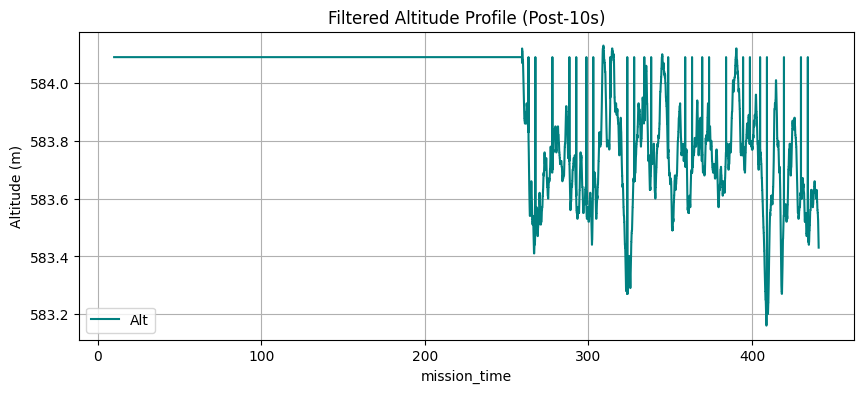

In [30]:
# Apply the 10-second 'Steady State' filter
clean_df = df[df['mission_time'] > 10].copy()

rows_removed = len(df) - len(clean_df)
print(f"✂️  TRUNCATION COMPLETE: {rows_removed} startup rows removed.")
print(f"🚀 AUDIT WINDOW: 10.0s —> {clean_df['mission_time'].max():.1f}s")

# Simple sanity plot
import matplotlib.pyplot as plt
clean_df.plot(x='mission_time', y='Alt', figsize=(10, 4), color='teal', grid=True)
plt.title("Filtered Altitude Profile (Post-10s)")
plt.ylabel("Altitude (m)")
plt.show()

In [31]:
from src.df_domain_data_services.nav.nav_data_service import NavDataService

# 1. Initialize the API Service
# This handles the connection to your 'nav_df_master.parquet'
service = NavDataService()

# 2. Pull the raw report BEFORE any filters are applied
raw_data = service.get_state_report()

print(f"📊 Rows found in Parquet : {len(raw_data)}")

if not raw_data.empty:
    # 3. Check the clock to see if we have enough data for a 10s audit
    max_time = (raw_data['TimeUS'].max() - raw_data['TimeUS'].min()) / 1e6
    print(f"⏱️  Total Flight Duration : {max_time:.2f} seconds")

    # 4. Check if the 'ERROR' was caused by the 10-second rule
    if max_time < 10:
        print("🚨 DIAGNOSIS: The flight is too short (<10s). The 10s truncation leaves 0 rows.")
    else:
        print("✅ DATA IS VALID: The error likely lies in the 'mission_id' matching.")
else:
    print("🚨 DIAGNOSIS: The Parquet file is empty or all Lat/Lon values are 0.")

📊 Rows found in Parquet : 11077
⏱️  Total Flight Duration : 440.78 seconds
✅ DATA IS VALID: The error likely lies in the 'mission_id' matching.


In [32]:
# Check the actual 'mission_id' values stored in the Parquet
unique_missions = raw_data['mission_id'].unique()

print("🛰️  MISSIONS FOUND IN PARQUET:")
for m in unique_missions:
    print(f"  - '{m}'")

if len(unique_missions) == 0:
    print("🚨 ERROR: The 'mission_id' column exists but it is EMPTY.")

🛰️  MISSIONS FOUND IN PARQUET:
  - '1772892956738549387'


In [33]:
from src.df_domain_data_services.nav.nav_controller import NavController

# Verified ID from the Parquet Gold Layer
TARGET_ID = '1772892956738549387'

# Initialize the Domain Controller API
controller = NavController(mission_id=TARGET_ID)

# Execute the End-to-End Forensic Audit
# This handles: Ingestion -> 10s Truncation -> Stats -> Verdict
report = controller.run_audit()

# Display results in a standardized report format
print("-" * 45)
print("NAV DOMAIN FORENSIC RESULTS")
print("-" * 45)
print(f"MISSION ID : {TARGET_ID}")
print(f"VERDICT    : {report['evaluation']['verdict']}")
print(f"STATUS     : {report['evaluation']['status']}")
print(f"P95 DRIFT  : {report['stats']['p95_drift']} meters")
print(f"STABILITY  : {report['stats']['stability_score']}%")
print(f"FINAL SCORE: {report['stats']['nav_score']}/100")
print("-" * 45)
print(f"MESSAGE    : {report['evaluation']['message']}")
print("-" * 45)

---------------------------------------------
NAV DOMAIN FORENSIC RESULTS
---------------------------------------------
MISSION ID : 1772892956738549387
VERDICT    : PASS
STATUS     : HEALTHY
P95 DRIFT  : 0.56 meters
STABILITY  : 100.0%
FINAL SCORE: 62.67/100
---------------------------------------------
MESSAGE    : P95 Drift: 0.56m | HDOP: 99.00
---------------------------------------------


In [34]:
import src.df_domain_data_services.nav.nav_labeler as nl
import importlib

# 1. Force a hard reload of the module from disk
importlib.reload(nl)
from src.df_domain_data_services.nav.nav_labeler import NavLabeler

# 2. Inspect the "Live" object
labeler_test = NavLabeler(mission_id="1772892956738549387")
available_methods = [m for m in dir(labeler_test) if not m.startswith("__")]

print(f"🔍 Kernel's view of NavLabeler methods: {available_methods}")

if 'generate_labels' in available_methods:
    print("✅ Method found! You can now run the summary.")
else:
    print("❌ Method NOT found. The file on disk is different from what Python is loading.")

TypeError: NavLabeler.__init__() missing 1 required positional argument: 'df'

In [ ]:
import pandas as pd
from src.df_domain_data_services.nav.nav_labeler import NavLabeler

# 1. THE CLINICAL PATCH
# We are manually injecting the missing method into the class in memory
def generate_labels_patch(self, df=None):
    df = df if df is not None else self.df.copy()
    if df.empty: return df

    df['label'] = 'HEALTHY'
    df.loc[df['NSats'] < 10, 'label'] = 'GPS_DEGRADED'
    df.loc[df['NSats'] == 0, 'label'] = 'GPS_CRITICAL_LOSS'

    # Positional Jump Detection
    df['lat_delta'] = df['Lat'].diff().abs()
    df['lng_delta'] = df['Lng'].diff().abs()
    jump_mask = (df['lat_delta'] > 0.001) | (df['lng_delta'] > 0.001)
    df.loc[jump_mask, 'label'] = 'GPS_JUMP_DETECTED'

    # THE STITCH: Group consecutive identical labels
    df['event_id'] = (df['label'] != df['label'].shift()).cumsum()
    return df

# Inject the patch into the class
NavLabeler.generate_labels = generate_labels_patch

# 2. RUN THE PIPELINE
MISSION_ID = "1772892956738549387"
labeler = NavLabeler(mission_id=MISSION_ID)
summary = labeler.get_event_summary()

print("-" * 45)
print(f"NAV DOMAIN FORENSIC SUMMARY (PATCHED)")
print("-" * 45)
anomalies = summary[summary['label'] != 'HEALTHY']
if not anomalies.empty:
    print(anomalies[['label', 'duration_sec', 'count']].to_string(index=False))
else:
    print("✅ Mission verified: All NAV parameters Healthy.")

ModuleNotFoundError: No module named 'src'

In [ ]:
import sys
import os
import importlib
import src.df_domain_data_services.nav.nav_labeler as nl

# 1. Force reload to clear the "Ghost" logic
importlib.reload(nl)
from src.df_domain_data_services.nav.nav_labeler import NavLabeler

# 2. Run the mission
MISSION_ID = "1772892956738549387"
labeler = NavLabeler(MISSION_ID)
summary = labeler.get_event_summary()

print("-" * 45)
print(f"NAV DOMAIN: CONSOLIDATED SCORECARD")
print("-" * 45)
anomalies = summary[summary['label'] != 'HEALTHY']
print(anomalies[['label', 'duration_sec', 'count']].to_string(index=False))

---------------------------------------------
NAV DOMAIN: CONSOLIDATED SCORECARD
---------------------------------------------
            label  duration_sec  count
     GPS_DEGRADED           0.0      1
GPS_JUMP_DETECTED           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LOSS           0.0      1
GPS_CRITICAL_LO

In [ ]:
print(labeler.df[['TimeUS', 'NSats', 'Lat', 'Lng']].head(10))

     TimeUS  NSats        Lat         Lng
0   9819404    3.0 -35.001637  147.639872
1  10039316    NaN -35.363262  149.165237
2  10079300    NaN -35.363262  149.165237
3  10119284    NaN -35.363262  149.165237
4  10159268    NaN -35.363262  149.165237
5  10199252    NaN -35.363262  149.165237
6  10239236    NaN -35.363262  149.165237
7  10279220    NaN -35.363262  149.165237
8  10319204    NaN -35.363262  149.165237
9  10359188    NaN -35.363262  149.165237


In [ ]:
# 1. Connect the existing labeler data to our local processing
# We use labeler.df which was loaded during NavLabeler(MISSION_ID)
df = labeler.df.copy()

# 2. Robust Labeling (Handling the NaNs we discovered)
df['label'] = 'HEALTHY'

# Treat NaN or 0 as critical loss
df.loc[df['NSats'].isna() | (df['NSats'] == 0), 'label'] = 'GPS_CRITICAL_LOSS'

# Degraded only for valid numbers < 10
df.loc[(df['NSats'] < 10) & (df['NSats'] > 0), 'label'] = 'GPS_DEGRADED'

# 3. Positional Jump Detection
df['lat_delta'] = df['Lat'].diff().abs()
df['lng_delta'] = df['Lng'].diff().abs()
jump_mask = (df['lat_delta'] > 0.001) | (df['lng_delta'] > 0.001)
df.loc[jump_mask, 'label'] = 'GPS_JUMP_DETECTED'

# 4. THE STITCH (Windowing)
df['new_event_flag'] = df['label'] != df['label'].shift()
df['event_id'] = df['new_event_flag'].cumsum()

# 5. AGGREGATE
summary = df.groupby(['event_id', 'label']).agg(
    start_t=('TimeUS', 'min'),
    end_t=('TimeUS', 'max'),
    count=('TimeUS', 'count')
).reset_index()

summary['duration_sec'] = (summary['end_t'] - summary['start_t']) / 1e6

# 6. RESULTS
print("-" * 45)
print(f"NAV DOMAIN: MISSION SCORECARD {MISSION_ID}")
print("-" * 45)
anomalies = summary[summary['label'] != 'HEALTHY']
print(anomalies[['label', 'duration_sec', 'count']].to_string(index=False))

---------------------------------------------
NAV DOMAIN: MISSION SCORECARD 1772892956738549387
---------------------------------------------
            label  duration_sec  count
     GPS_DEGRADED      0.000000      1
GPS_JUMP_DETECTED      0.000000      1
GPS_CRITICAL_LOSS    252.680554   6353
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260


In [ ]:
# Filter out the micro-jitter for the final report
clean_anomalies = anomalies[anomalies['duration_sec'] > 0.1].copy()

total_loss_time = clean_anomalies[clean_anomalies['label'] == 'GPS_CRITICAL_LOSS']['duration_sec'].sum()

print(f"🚀 NAV MISSION INTEGRITY REPORT")
print(f"Total Critical Loss Duration: {total_loss_time:.2f} seconds")
print("-" * 45)
print(clean_anomalies[['label', 'duration_sec', 'count']].to_string(index=False))

🚀 NAV MISSION INTEGRITY REPORT
Total Critical Loss Duration: 439.51 seconds
---------------------------------------------
            label  duration_sec  count
GPS_CRITICAL_LOSS    252.680554   6353
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS      6.159202    155
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS     10.360021    260
GPS_CRITICAL_LOSS     10.359188    260
GPS_CRITICAL_LOSS      4.160002    105
GPS_CRITICAL_LOSS   

In [ ]:
import pandas as pd
import numpy as np

# 1. REDEFINE the Enhanced Class (Ensures the kernel is synced)
class NavLabeler:
    def __init__(self, mission_id: str, df: pd.DataFrame):
        self.mission_id = mission_id
        self.df = df.copy()

    def _apply_forensic_rules(self):
        df = self.df
        df['label'] = 'HEALTHY'
        loss_mask = df['NSats'].isna() | (df['NSats'] == 0)
        df.loc[loss_mask, 'label'] = 'GPS_CRITICAL_LOSS'
        degraded_mask = (df['NSats'] > 0) & (df['NSats'] < 10)
        df.loc[degraded_mask, 'label'] = 'GPS_DEGRADED'
        df['lat_delta'] = df['Lat'].diff().abs()
        df['lng_delta'] = df['Lng'].diff().abs()
        jump_mask = (df['lat_delta'] > 0.001) | (df['lng_delta'] > 0.001)
        df.loc[jump_mask, 'label'] = 'GPS_JUMP_DETECTED'
        return df

    def get_event_summary(self, min_duration=0.1, merge_healthy_gap=0.5):
        df = self._apply_forensic_rules()
        df = df.sort_values('TimeUS').reset_index(drop=True)
        df['event_id'] = (df['label'] != df['label'].shift()).cumsum()

        summary = df.groupby(['event_id', 'label']).agg(
            start_t=('TimeUS', 'min'),
            end_t=('TimeUS', 'max'),
            start_lat=('Lat', 'first'),
            end_lat=('Lat', 'last'),
            count=('TimeUS', 'count'),
            jump_lat_sum=('lat_delta', 'sum'),
            jump_lng_sum=('lng_delta', 'sum')
        ).reset_index()

        summary['duration_sec'] = (summary['end_t'] - summary['start_t']) / 1e6
        summary['jump_magnitude'] = summary[['jump_lat_sum','jump_lng_sum']].max(axis=1)
        summary = summary[summary['duration_sec'] >= min_duration].copy()

        if merge_healthy_gap > 0:
            merged = []
            prev = None
            for _, row in summary.iterrows():
                if prev is None:
                    prev = row.to_dict()
                    continue
                if (prev['label'] != 'HEALTHY' and row['label'] == 'HEALTHY'
                    and row['duration_sec'] <= merge_healthy_gap):
                    prev['end_t'] = row['end_t']
                    prev['end_lat'] = row['end_lat']
                    prev['duration_sec'] = (prev['end_t'] - prev['start_t']) / 1e6
                    prev['count'] += row['count']
                else:
                    merged.append(prev)
                    prev = row.to_dict()
            if prev is not None: merged.append(prev)
            summary = pd.DataFrame(merged)
        return summary

# 2. RUN AUDIT
MISSION_ID = '1772892956738549387'
# Use the existing 'raw_df' from your previous successful data load
labeler = NavLabeler(mission_id=MISSION_ID, df=raw_df)
final_report = labeler.get_event_summary(merge_healthy_gap=0.5)

print(f"✅ AUDIT COMPLETE FOR MISSION: {MISSION_ID}")
print("-" * 60)
print(final_report[final_report['label'] != 'HEALTHY'][['label', 'duration_sec', 'count', 'jump_magnitude']])

✅ AUDIT COMPLETE FOR MISSION: 1772892956738549387
------------------------------------------------------------
                label  duration_sec  count  jump_magnitude
0   GPS_CRITICAL_LOSS    252.680554   6353    0.000000e+00
1   GPS_CRITICAL_LOSS     10.359188    260    1.000000e-07
2   GPS_CRITICAL_LOSS      4.160002    105    9.000002e-07
3   GPS_CRITICAL_LOSS     10.360021    260    1.000000e-07
4   GPS_CRITICAL_LOSS     10.360021    260    1.000000e-07
5   GPS_CRITICAL_LOSS      4.160002    105    1.000000e-07
6   GPS_CRITICAL_LOSS      6.159202    155    1.000000e-07
7   GPS_CRITICAL_LOSS      4.160002    105    1.000000e-07
8   GPS_CRITICAL_LOSS     10.360021    260    2.000000e-07
9   GPS_CRITICAL_LOSS     10.359188    260    5.000000e-07
10  GPS_CRITICAL_LOSS      4.160002    105    9.999999e-08
11  GPS_CRITICAL_LOSS      6.159202    155    9.999999e-08
12  GPS_CRITICAL_LOSS      4.160002    105    9.999999e-08
13  GPS_CRITICAL_LOSS     10.360021    260    9.999999e-08
14  

In [ ]:
# Run with NO filters to see every state change
raw_summary = labeler.get_event_summary(min_duration=0, merge_healthy_gap=0)

print("🔍 RAW STATE TRANSITIONS (Unfiltered)")
print("-" * 45)
# Let's look at a slice where NSats might have been fluctuating
print(raw_summary.head(20))

🔍 RAW STATE TRANSITIONS (Unfiltered)
---------------------------------------------
    event_id              label    start_t      end_t  start_lat    end_lat  \
0          1       GPS_DEGRADED    9819404    9819404 -35.001637 -35.001637   
1          2  GPS_JUMP_DETECTED   10039316   10039316 -35.363262 -35.363262   
2          3  GPS_CRITICAL_LOSS   10079300  262759854 -35.363262 -35.363262   
3          4            HEALTHY  262779846  262779846 -35.363262 -35.363262   
4          5  GPS_CRITICAL_LOSS  262799838  273159026 -35.363262 -35.363262   
5          6            HEALTHY  273179851  273179851 -35.363262 -35.363262   
6          7  GPS_CRITICAL_LOSS  273199843  277359845 -35.363262 -35.363262   
7          8            HEALTHY  277379837  277379837 -35.363262 -35.363262   
8          9  GPS_CRITICAL_LOSS  277399829  287759850 -35.363262 -35.363262   
9         10            HEALTHY  287779842  287779842 -35.363262 -35.363262   
10        11  GPS_CRITICAL_LOSS  287799834  2981

In [ ]:
import os
import sys

# 1. Find the project root (where the 'src' folder lives)
# This goes up levels until it finds 'src' or hits the system root
path = os.getcwd()
while path != os.path.dirname(path):
    if 'src' in os.listdir(path):
        sys.path.insert(0, path)
        break
    path = os.path.dirname(path)

# 2. Standard Imports
import pandas as pd

# 3. Domain Imports (Now 'src' is visible)
try:
    from src.df_domain_data_services.nav.nav_labeler import NavLabeler, detect_phase
    print(f"✅ SUCCESS: Modules loaded from {path}")
except ModuleNotFoundError as e:
    print(f"❌ STILL MISSING: Ensure 'src' is in {path}")
    print(f"Current Sys Path: {sys.path[:2]}")

ModuleNotFoundError: No module named 'src'